# Project: Automobile-Insights

## GroupBy and Aggregate Functions

### Group by Definition :

###### In Python's pandas library, the .groupby() function is a powerful tool for splitting a DataFrame into groups based on one or more criteria, applying a function to each group independently, and then combining the results into a new data structure.

###### It is used alongside aggregate functions like COUNT(), SUM(), AVG(), MAX(), or MIN() to perform calculations on each group rather than the entire dataset.

In [1]:
import pandas as pd

In [2]:
df_cars = pd.read_csv(r'C:\Users\TRUPTI\Downloads\Car_sales (1).csv')

In [3]:
df_cars

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Volvo,V40,3.545,NaN,Passenger,24.40,1.9,160.0,100.5,67.6,176.6,3.042,15.8,25.0,9/21/2011,66.498812
153,Volvo,S70,15.245,NaN,Passenger,27.50,2.4,168.0,104.9,69.3,185.9,3.208,17.9,25.0,11/24/2012,70.654495
154,Volvo,V70,17.531,NaN,Passenger,28.80,2.4,168.0,104.9,69.3,186.2,3.259,17.9,25.0,6/25/2011,71.155978
155,Volvo,C70,3.493,NaN,Passenger,45.50,2.3,236.0,104.9,71.5,185.7,3.601,18.5,23.0,4/26/2011,101.623357


In [4]:
df_cars.nunique()

Manufacturer            30
Model                  156
Sales_in_thousands     157
__year_resale_value    117
Vehicle_type             2
Price_in_thousands     152
Engine_size             31
Horsepower              66
Wheelbase               88
Width                   78
Length                 127
Curb_weight            147
Fuel_capacity           55
Fuel_efficiency         20
Latest_Launch          130
Power_perf_factor      154
dtype: int64

## agg()

In [5]:
df_cars.agg('sum')

Manufacturer           AcuraAcuraAcuraAcuraAudiAudiAudiBMWBMWBMWBuick...
Model                  IntegraTLCLRLA4A6A8323i328i528iCenturyRegalPar...
Sales_in_thousands                                              8320.698
__year_resale_value                                              2186.83
Vehicle_type           PassengerPassengerPassengerPassengerPassengerP...
Price_in_thousands                                              4245.567
Engine_size                                                        477.5
Horsepower                                                       29008.0
Wheelbase                                                        16768.0
Width                                                            11099.4
Length                                                           29225.6
Curb_weight                                                      523.594
Fuel_capacity                                                     2800.5
Fuel_efficiency                                    

## groupby()

In [6]:
df_cars.groupby('Vehicle_type')['Sales_in_thousands'].mean()

Vehicle_type
Car          80.622293
Passenger    43.234345
Name: Sales_in_thousands, dtype: float64

In [7]:
df_cars.groupby('Vehicle_type')[['Sales_in_thousands', 
                                'Price_in_thousands', 
                                'Engine_size', 
                                'Horsepower', 
                                'Fuel_capacity']].mean()

,Sales_in_thousands,Price_in_thousands,Engine_size,Horsepower,Fuel_capacity
Vehicle_type,,,,,
Car,80.622293,26.319975,3.520000,186.400000,21.895000
Passenger,43.234345,27.763200,2.902586,185.793103,16.592241


# Pie Chart

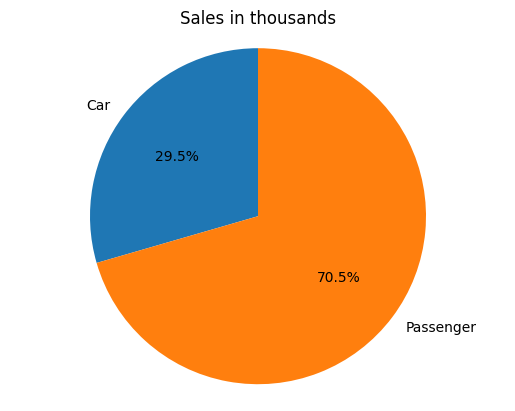

In [8]:
import matplotlib.pyplot as plt

Sales_in_thousands = df_cars.groupby('Vehicle_type')['Engine_size'].sum()

plt.pie(
    Sales_in_thousands,
    labels=Sales_in_thousands.index,
    autopct='%.1f%%',
    startangle=90,
)

plt.title('Sales in thousands')
plt.axis('equal')
plt.show()

# Donut Chart

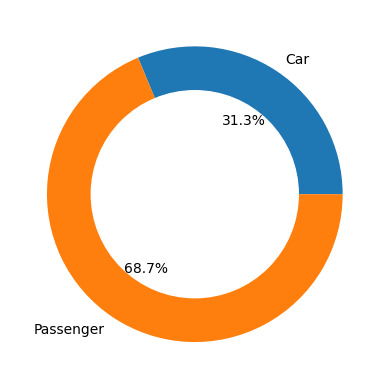

In [10]:
import matplotlib.pyplot as plt

data = df_cars.groupby('Vehicle_type')['Fuel_capacity'].sum()

plt.pie(data, labels=data.index, autopct='%.1f%%')
plt.gca().add_artist(plt.Circle((0,0), 0.7, color='white'))

plt.show()

# Scatter Chart

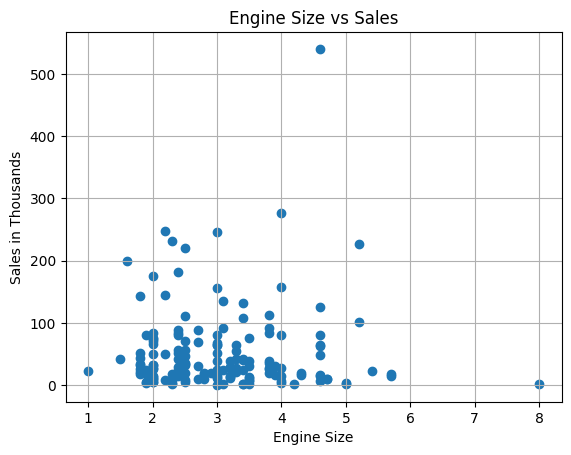

In [12]:
import matplotlib.pyplot as plt

plt.scatter(df_cars['Engine_size'], df_cars['Sales_in_thousands'])

plt.xlabel('Engine Size')
plt.ylabel('Sales in Thousands')
plt.title('Engine Size vs Sales')

plt.grid()

plt.show()

# Line Chart

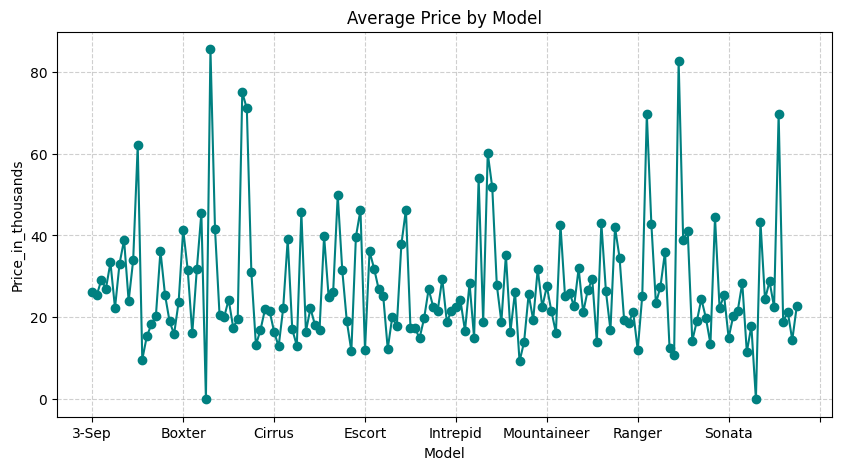

In [13]:
import matplotlib.pyplot as plt

sales_by_year = df_cars.groupby('Model')['Price_in_thousands'].sum()

sales_by_year.plot(kind='line', marker='o', color='teal', figsize=(10,5))

plt.title('Average Price by Model')
plt.xlabel('Model')
plt.ylabel('Price_in_thousands')
plt.grid(True, linestyle='--',alpha=0.6)
plt.show()

# Funnel Chart

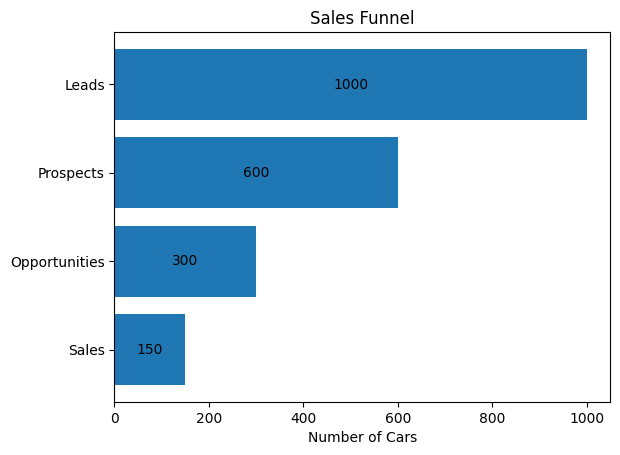

In [14]:
import matplotlib.pyplot as plt

stages = ['Leads', 'Prospects', 'Opportunities', 'Sales']
values = [1000, 600, 300, 150]

plt.barh(stages, values)

# Center bars (funnel shape)
max_val = max(values)
for i, v in enumerate(values):
    plt.text(v/2, i, str(v), ha='center', va='center')

plt.gca().invert_yaxis()
plt.title('Sales Funnel')
plt.xlabel('Number of Cars')

plt.show()

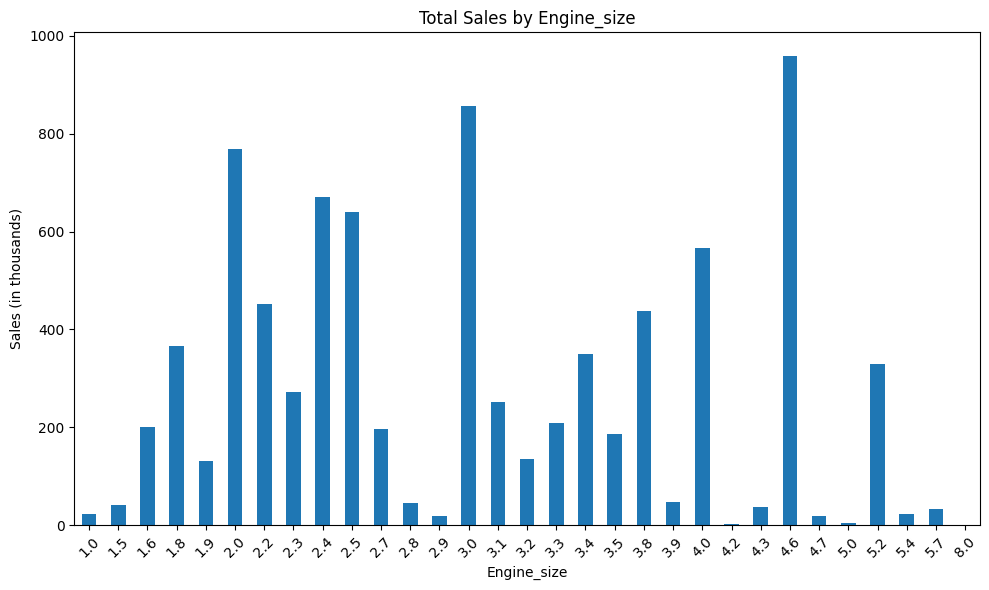

In [15]:
import matplotlib.pyplot as plt
# Groupby
sales_by_manufacturer = df_cars.groupby('Engine_size')['Sales_in_thousands'].sum()

# Plot
sales_by_manufacturer.plot(kind='bar', figsize=(10,6))

plt.title('Total Sales by Engine_size')
plt.xlabel('Engine_size')
plt.ylabel('Sales (in thousands)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Stacked Bar Chart

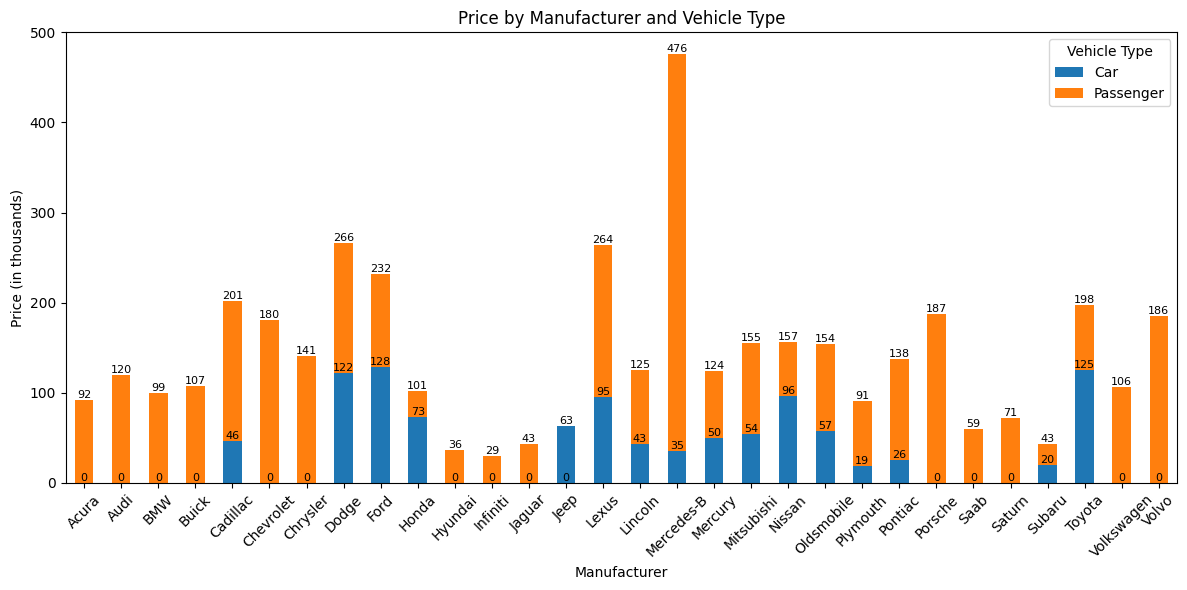

In [16]:
import matplotlib.pyplot as plt
# Groupby + unstack
data = df_cars.groupby(['Manufacturer', 'Vehicle_type'])['Price_in_thousands'].sum().unstack()

# Plot stacked bar
ax=data.plot(kind='bar', stacked=True, figsize=(12,6))
for c in ax.containers: 
    ax.bar_label(c, fmt='%.0f', label_type='edge', fontsize=8)

plt.title('Price by Manufacturer and Vehicle Type')
plt.xlabel('Manufacturer')
plt.ylabel('Price (in thousands)')
plt.xticks(rotation=45)
plt.legend(title='Vehicle Type')
plt.tight_layout()
plt.show()